# Arquitectura Inception

Este notebook presenta la arquitectura **Inception / GoogLeNet** desde la motivación conceptual hasta una implementación práctica en Keras. La idea no es solo leer la teoría, sino **ver diagramas, comparar costos computacionales y entrenar pequeñas variantes tipo Inception**.

**Información del curso**
* **Curso:** Redes neuronales 2019781
* **Profesor:** Luis Fernando Niño Vasquez
* **Semestre:** 2026-1

**Miembros del equipo**

| Nombre | Correo |
| :--- | :--- |
| **David Felipe Marin Rosas** | dmarinro@unal.edu.co |
| **Laura Camila Girón Pinto** | lgironp@unal.edu.co |
| **Nicolas Martinez Lopez** | nmartinezl@unal.edu.co |
| **Diego Esteban Morales Granados** |dimorales@unal.edu.co|
| **Sergio Ivan Motta Doncel** | smottad@unal.edu.co |

> Recomendación: ejecuta primero las secciones visuales y luego el entrenamiento con pocas épocas. Si estás en Google Colab, activa GPU para acelerar los ejemplos.

## 1. Introducción

### ¿Qué es la arquitectura Inception?

**Inception** es una familia de arquitecturas convolucionales que introdujo una idea poderosa: en vez de escoger un único tamaño de filtro para cada capa, se procesan las mismas activaciones con **varias ramas en paralelo**. Por ejemplo, una rama puede usar convoluciones `1x1`, otra `3x3`, otra `5x5` y otra `MaxPooling`. Luego, todas las salidas se concatenan por canales.

### ¿Por qué fue importante?

Antes de Inception, muchas redes profundas crecían principalmente apilando capas de forma secuencial. Inception propuso una forma más eficiente de aumentar la capacidad de representación:

- Captura patrones a diferentes escalas en el mismo nivel de la red.
- Reduce costo computacional con convoluciones `1x1`.
- Permite construir redes más profundas sin disparar tanto el número de parámetros.
- Fue la base de **GoogLeNet**, ganadora de ILSVRC 2014.

### Objetivos del notebook

Al terminar, deberías poder:

- Explicar qué problema resuelve Inception.
- Dibujar y entender un módulo Inception.
- Calcular por qué las convoluciones `1x1` reducen parámetros.
- Implementar un módulo Inception en Keras.
- Entrenar y evaluar una pequeña red tipo Inception.

## 2. Conceptos previos: CNN en breve

Una **red neuronal convolucional** o **CNN** procesa datos con estructura espacial, especialmente imágenes. En lugar de conectar cada pixel con todas las neuronas, usa filtros pequeños que se deslizan sobre la imagen.

### Convoluciones y mapas de características

Una convolución aplica un filtro, por ejemplo `3x3`, sobre regiones locales de la imagen. Cada filtro aprende a detectar un patrón: bordes, texturas, formas o partes de objetos. El resultado de aplicar un filtro se llama **mapa de características**.

### Pooling

El pooling reduce la resolución espacial. Un `MaxPooling2D(2x2)` conserva el valor máximo de cada ventana `2x2`, reduciendo ancho y alto. Esto ayuda a disminuir costo y aporta cierta invariancia a pequeñas traslaciones.

### El problema del tamaño del filtro

Elegir filtros pequeños o grandes no es trivial:

- `1x1`: mezcla canales y puede reducir dimensionalidad.
- `3x3`: detecta patrones locales compactos.
- `5x5`: cubre un campo visual mayor, pero es más costoso.

Inception pregunta: **¿por qué escoger uno solo si podemos usar varios en paralelo?**

## 3. Motivación de Inception

Las arquitecturas anteriores enfrentaban varios problemas:

- Al aumentar profundidad y ancho, crecía mucho el costo computacional.
- Un único tamaño de filtro podía ser insuficiente para capturar patrones de escalas diferentes.
- Filtros grandes como `5x5` aportaban contexto, pero eran caros.
- Diseñar manualmente qué tamaño de filtro usar en cada capa era una decisión rígida.

La idea central de Inception es construir un bloque que pueda mirar la entrada con varias "lentes" al mismo tiempo:

- Una lente `1x1` para mezclar canales y reducir dimensionalidad.
- Una lente `3x3` para patrones locales.
- Una lente `5x5` para patrones más amplios.
- Una ruta de pooling para resumir presencia de características.

Así, la red aprende qué escala le conviene usar en cada etapa.

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Entorno base listo.")

Entorno base listo.


## 4. El módulo Inception

Un módulo Inception recibe un tensor de entrada y lo procesa con varias ramas:

1. **Rama `1x1`**: convolución `1x1`.
2. **Rama `3x3`**: usualmente `1x1` para reducir canales y luego `3x3`.
3. **Rama `5x5`**: usualmente `1x1` para reducir canales y luego `5x5`.
4. **Rama de Max Pooling**: pooling seguido de `1x1`.
5. **Concatenación**: se unen las salidas por la dimensión de canales.

El siguiente diagrama resume el bloque fundamental.

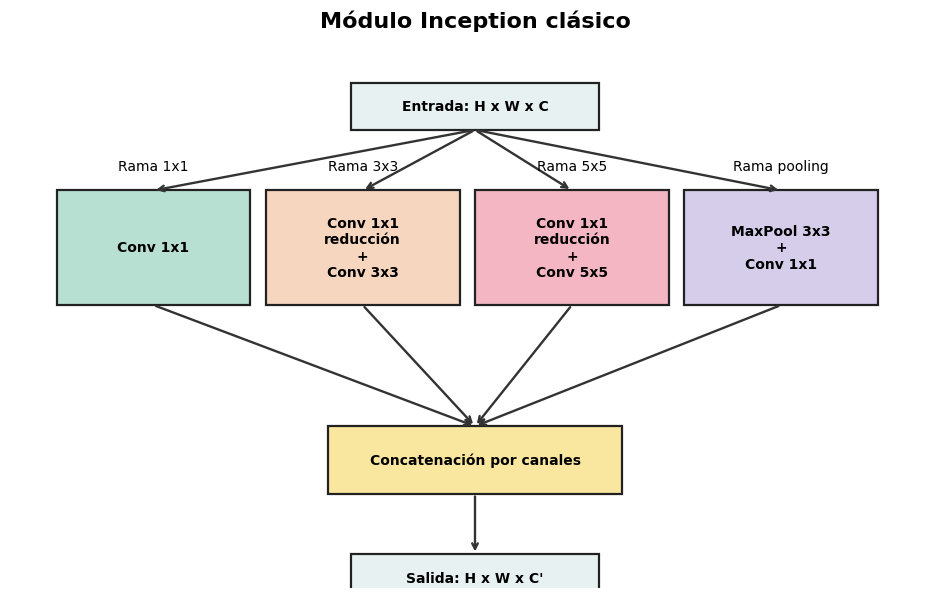

In [ ]:
def draw_inception_module():
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 8)
    ax.axis("off")

    def box(x, y, w, h, text, color):
        rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="#222", linewidth=1.6)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10, weight="bold")

    def arrow(x1, y1, x2, y2):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.7, color="#333"))

    colors = {
        "input": "#E8F1F2",
        "conv1": "#B8E0D2",
        "conv3": "#F7D6BF",
        "conv5": "#F4B6C2",
        "pool": "#D6CDEA",
        "concat": "#F9E79F",
    }

    box(4.4, 6.8, 3.2, 0.7, "Entrada: H x W x C", colors["input"])

    branches = [
        (0.6, "Conv 1x1", "Rama 1x1", colors["conv1"]),
        (3.3, "Conv 1x1\nreducción\n+\nConv 3x3", "Rama 3x3", colors["conv3"]),
        (6.0, "Conv 1x1\nreducción\n+\nConv 5x5", "Rama 5x5", colors["conv5"]),
        (8.7, "MaxPool 3x3\n+\nConv 1x1", "Rama pooling", colors["pool"]),
    ]

    for x, main, label, color in branches:
        arrow(6, 6.8, x + 1.25, 5.9)
        box(x, 4.2, 2.5, 1.7, main, color)
        ax.text(x + 1.25, 6.15, label, ha="center", va="bottom", fontsize=10)
        arrow(x + 1.25, 4.2, 6, 2.4)

    box(4.1, 1.4, 3.8, 1.0, "Concatenación por canales", colors["concat"])
    arrow(6, 1.4, 6, 0.5)
    box(4.4, -0.2, 3.2, 0.7, "Salida: H x W x C'", colors["input"])

    ax.set_title("Módulo Inception clásico", fontsize=16, weight="bold", pad=16)
    plt.show()

draw_inception_module()

## 5. Convoluciones `1x1`: la clave de la eficiencia

Una convolución `1x1` no mira vecindarios espaciales; mira todos los canales en una misma posición. Esto permite:

- Mezclar información entre canales.
- Reducir profundidad antes de una convolución costosa.
- Disminuir parámetros y operaciones.

### Ejemplo numérico

Supongamos una entrada de `28 x 28 x 192` y queremos aplicar `32` filtros `5x5`.

Sin reducción:

`5 x 5 x 192 x 32 = 153,600` parámetros.

Con reducción previa a `16` canales:

`1 x 1 x 192 x 16 + 5 x 5 x 16 x 32 = 3,072 + 12,800 = 15,872` parámetros.

Esto es casi **10 veces menos**.

In [ ]:
def conv_params(k, in_channels, out_channels, bias=True):
    return k * k * in_channels * out_channels + (out_channels if bias else 0)

def inception_savings(in_channels=192, reduced_channels=16, out_channels=32, kernel=5):
    without = conv_params(kernel, in_channels, out_channels, bias=False)
    with_reduction = conv_params(1, in_channels, reduced_channels, bias=False) + conv_params(kernel, reduced_channels, out_channels, bias=False)
    return without, with_reduction, without / with_reduction

rows = []
for reduced in [8, 16, 32, 48, 64]:
    without, with_reduction, ratio = inception_savings(reduced_channels=reduced)
    rows.append({
        "Canales tras 1x1": reduced,
        "Parámetros sin reducción": without,
        "Parámetros con reducción": with_reduction,
        "Ahorro relativo": f"{ratio:.2f}x",
    })

pd.DataFrame(rows)

,Canales tras 1x1,Parámetros sin reducción,Parámetros con reducción,Ahorro relativo
0,8,153600,7936,19.35x
1,16,153600,15872,9.68x
2,32,153600,31744,4.84x
3,48,153600,47616,3.23x
4,64,153600,63488,2.42x


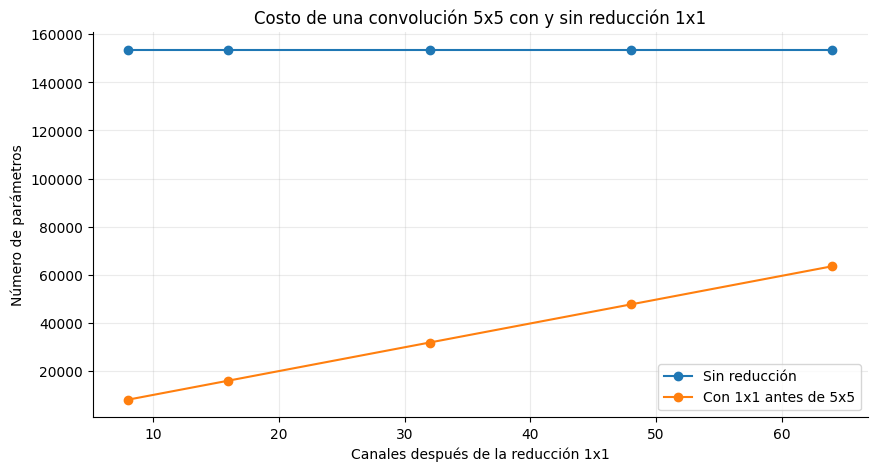

In [ ]:
df = pd.DataFrame(rows)
plt.figure(figsize=(10, 5))
plt.plot(df["Canales tras 1x1"], df["Parámetros sin reducción"], marker="o", label="Sin reducción")
plt.plot(df["Canales tras 1x1"], df["Parámetros con reducción"], marker="o", label="Con 1x1 antes de 5x5")
plt.title("Costo de una convolución 5x5 con y sin reducción 1x1")
plt.xlabel("Canales después de la reducción 1x1")
plt.ylabel("Número de parámetros")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 6. Arquitectura GoogLeNet / Inception v1

**GoogLeNet**, también conocida como **Inception v1**, integró muchos módulos Inception en una red profunda. Sus componentes principales fueron:

- Convoluciones iniciales para extraer características básicas.
- Apilamiento de módulos Inception.
- Clasificadores auxiliares en capas intermedias para mejorar el flujo del gradiente durante entrenamiento.
- **Global Average Pooling** al final, reduciendo parámetros frente a capas densas enormes.
- Clasificador final con softmax.

En ImageNet, GoogLeNet logró un rendimiento histórico y ganó ILSVRC 2014. Su importancia no fue solo obtener buen resultado, sino mostrar que una arquitectura podía ser más inteligente en el uso de parámetros.

### Diferencia entre GoogLeNet e Inception

Es común que se confundan los términos *GoogLeNet* e *Inception*, pero la relación es sencilla:

*   **Inception (módulo):** Es el **bloque de construcción fundamental** o la **idea conceptual** de una arquitectura de red neuronal convolucional. Un módulo Inception es una capa que procesa las entradas a través de múltiples filtros de diferentes tamaños (1x1, 3x3, 5x5, y pooling) en paralelo, y luego concatena sus salidas. El objetivo es permitir que la red aprenda a capturar patrones a diferentes escalas simultáneamente, mientras se mantiene la eficiencia computacional mediante el uso de convoluciones 1x1 para la reducción de dimensionalidad.

*   **GoogLeNet (red):** Es el **nombre de la arquitectura completa** de red neuronal profunda que ganó el desafío ILSVRC 2014. Esta arquitectura está compuesta por **múltiples módulos Inception** apilados, junto con otras capas tradicionales como convoluciones iniciales, capas de pooling, clasificadores auxiliares y una capa final de *Global Average Pooling* seguida de una capa densa para la clasificación. Por lo tanto, GoogLeNet es una red que **utiliza los módulos Inception** como su componente principal.

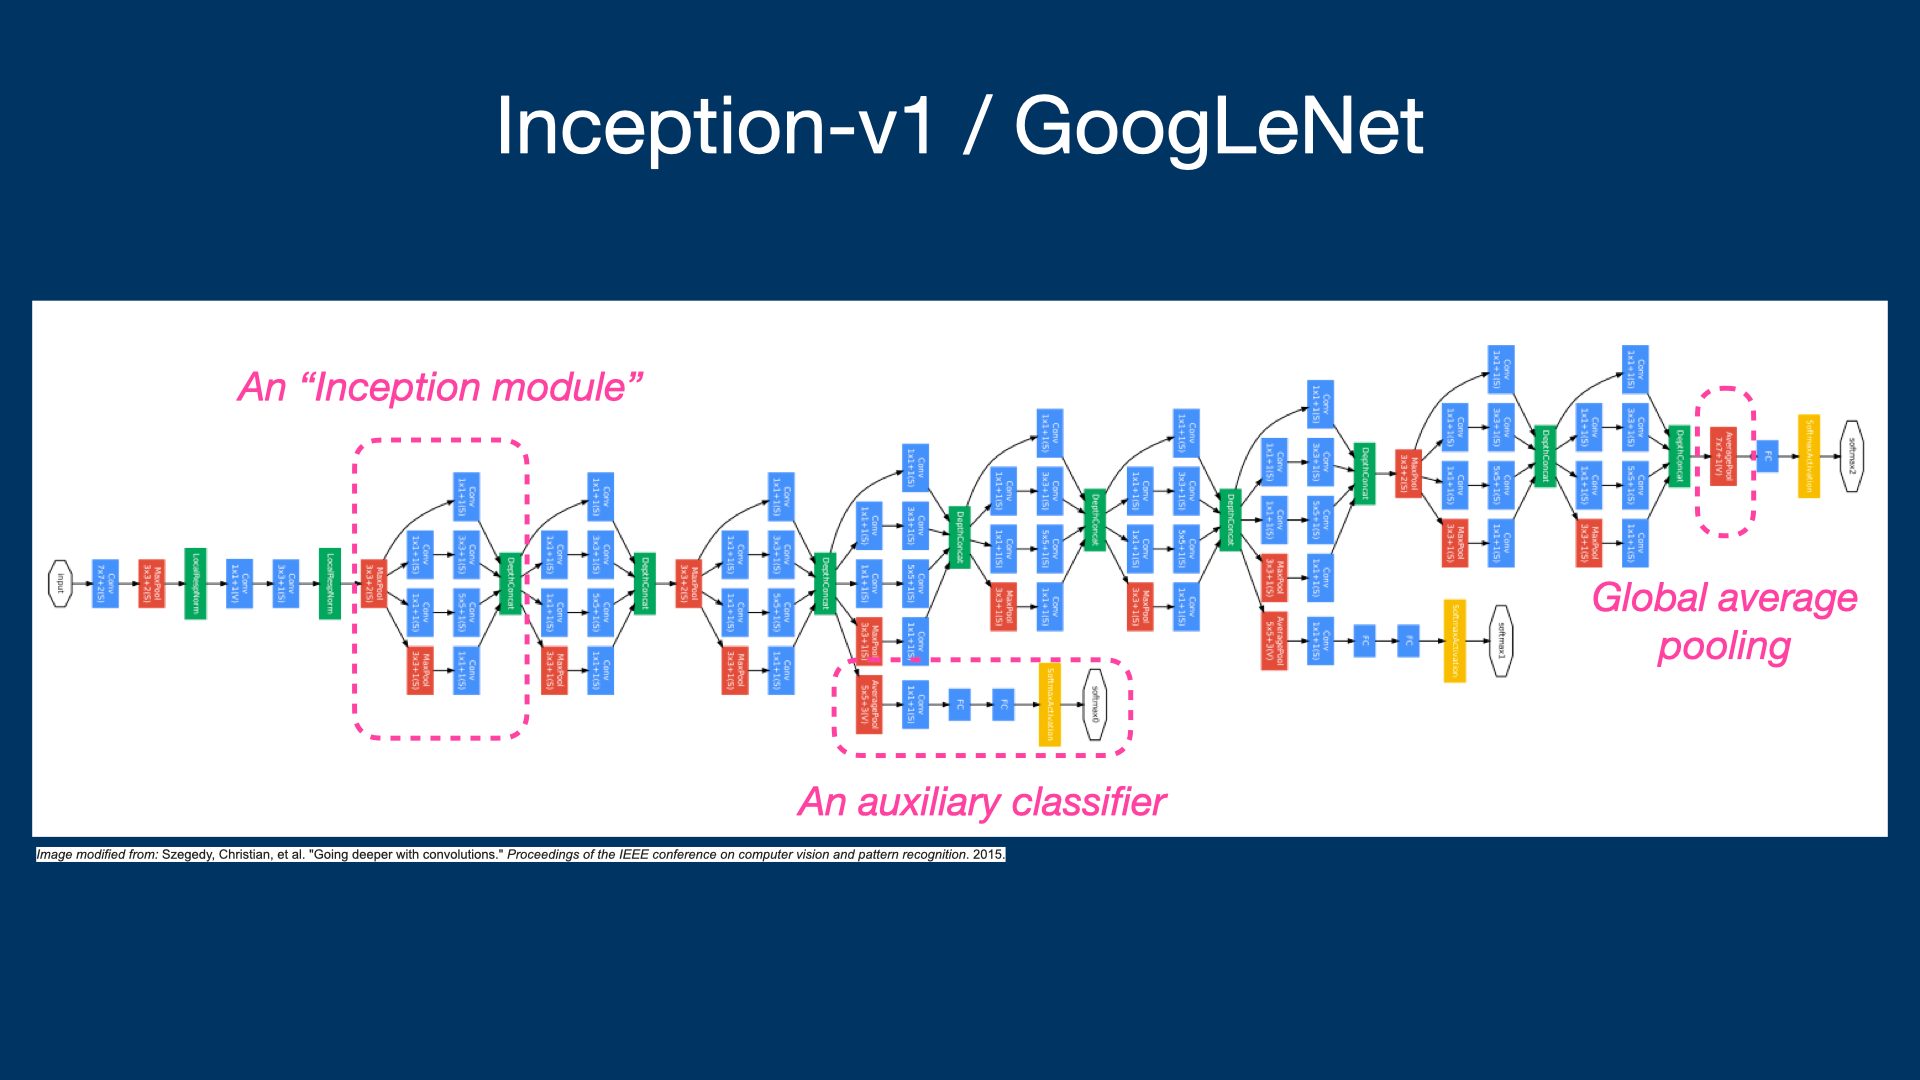

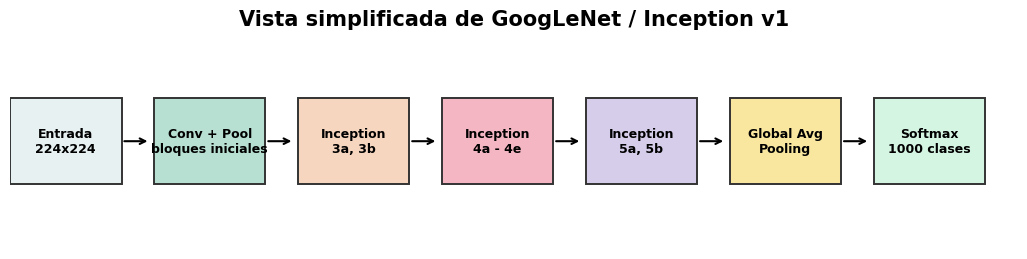

In [ ]:
def draw_googlenet_timeline():
    stages = [
        ("Entrada\n224x224", "#E8F1F2"),
        ("Conv + Pool\nbloques iniciales", "#B8E0D2"),
        ("Inception\n3a, 3b", "#F7D6BF"),
        ("Inception\n4a - 4e", "#F4B6C2"),
        ("Inception\n5a, 5b", "#D6CDEA"),
        ("Global Avg\nPooling", "#F9E79F"),
        ("Softmax\n1000 clases", "#D5F5E3"),
    ]
    fig, ax = plt.subplots(figsize=(13, 2.8))
    ax.axis("off")
    ax.set_xlim(0, len(stages) * 2)
    ax.set_ylim(0, 2)

    for i, (label, color) in enumerate(stages):
        x = i * 2
        rect = plt.Rectangle((x, 0.6), 1.55, 0.8, facecolor=color, edgecolor="#333", linewidth=1.4)
        ax.add_patch(rect)
        ax.text(x + 0.775, 1.0, label, ha="center", va="center", fontsize=9, weight="bold")
        if i < len(stages) - 1:
            ax.annotate("", xy=(x + 1.95, 1.0), xytext=(x + 1.55, 1.0),
                        arrowprops=dict(arrowstyle="->", lw=1.5))

    ax.set_title("Vista simplificada de GoogLeNet / Inception v1", fontsize=15, weight="bold")
    plt.show()

draw_googlenet_timeline()

## 7. Evolución de la arquitectura

Inception no fue una sola red, sino una familia que evolucionó incorporando ideas nuevas.

In [ ]:
evolution = pd.DataFrame({
    "Versión": ["v1", "v2", "v3", "v4", "Inception-ResNet"],
    "Mejora principal": [
        "Módulos paralelos multi-escala",
        "Batch Normalization",
        "Factorización de convoluciones",
        "Arquitectura optimizada y más uniforme",
        "Conexiones residuales"
    ],
    "Idea clave": [
        "Procesar la misma entrada con filtros 1x1, 3x3, 5x5 y pooling.",
        "Estabilizar y acelerar el entrenamiento.",
        "Reemplazar convoluciones grandes por combinaciones más baratas, como 1x3 + 3x1.",
        "Diseñar bloques Inception más refinados.",
        "Combinar módulos Inception con aprendizaje residual."
    ]
})

evolution

,Versión,Mejora principal,Idea clave
0,v1,Módulos paralelos multi-escala,"Procesar la misma entrada con filtros 1x1, 3x3..."
1,v2,Batch Normalization,Estabilizar y acelerar el entrenamiento.
2,v3,Factorización de convoluciones,Reemplazar convoluciones grandes por combinaci...
3,v4,Arquitectura optimizada y más uniforme,Diseñar bloques Inception más refinados.
4,Inception-ResNet,Conexiones residuales,Combinar módulos Inception con aprendizaje res...


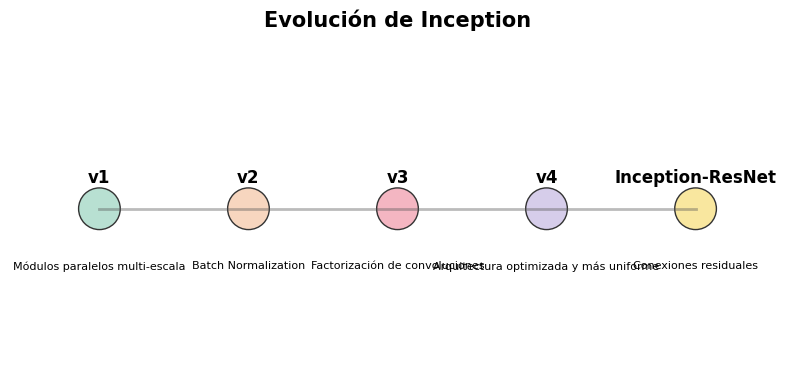

In [ ]:
plt.figure(figsize=(10, 4.5))
versions = evolution["Versión"]
levels = [1, 2, 3, 4, 5]
plt.scatter(levels, [1] * len(levels), s=900, c=["#B8E0D2", "#F7D6BF", "#F4B6C2", "#D6CDEA", "#F9E79F"], edgecolor="#333")
for x, version, idea in zip(levels, versions, evolution["Mejora principal"]):
    plt.text(x, 1.05, version, ha="center", va="bottom", fontsize=12, weight="bold")
    plt.text(x, 0.88, idea, ha="center", va="top", fontsize=8, wrap=True)
plt.plot(levels, [1] * len(levels), color="#555", linewidth=2, alpha=0.4)
plt.ylim(0.6, 1.4)
plt.xlim(0.4, 5.6)
plt.axis("off")
plt.title("Evolución de Inception", fontsize=15, weight="bold")
plt.show()

## 8. Implementación de un módulo Inception en Keras

La implementación sigue exactamente la idea del diagrama:

- Crear varias ramas.
- Aplicar convoluciones o pooling.
- Concatenar por canales.

La función siguiente recibe un tensor de entrada y devuelve el tensor concatenado. La misma función se puede reutilizar para construir redes más grandes.

In [ ]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print("TensorFlow:", tf.__version__)
except Exception as exc:
    tf = None
    keras = None
    layers = None
    print("TensorFlow no está disponible en este entorno.")
    print("En Colab normalmente basta con ejecutar: import tensorflow as tf")
    print("Detalle:", exc)

TensorFlow: 2.20.0


In [ ]:
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5, filters_pool_proj,
                     name=None):
    # Módulo Inception v1 simplificado.
    if layers is None:
        raise ImportError("TensorFlow/Keras no está disponible.")

    branch_1x1 = layers.Conv2D(filters_1x1, 1, padding="same", activation="relu",
                               name=None if name is None else f"{name}_1x1")(x)

    branch_3x3 = layers.Conv2D(filters_3x3_reduce, 1, padding="same", activation="relu",
                               name=None if name is None else f"{name}_3x3_reduce")(x)
    branch_3x3 = layers.Conv2D(filters_3x3, 3, padding="same", activation="relu",
                               name=None if name is None else f"{name}_3x3")(branch_3x3)

    branch_5x5 = layers.Conv2D(filters_5x5_reduce, 1, padding="same", activation="relu",
                               name=None if name is None else f"{name}_5x5_reduce")(x)
    branch_5x5 = layers.Conv2D(filters_5x5, 5, padding="same", activation="relu",
                               name=None if name is None else f"{name}_5x5")(branch_5x5)

    branch_pool = layers.MaxPooling2D(3, strides=1, padding="same",
                                      name=None if name is None else f"{name}_pool")(x)
    branch_pool = layers.Conv2D(filters_pool_proj, 1, padding="same", activation="relu",
                                name=None if name is None else f"{name}_pool_proj")(branch_pool)

    return layers.Concatenate(axis=-1, name=None if name is None else f"{name}_concat")(
        [branch_1x1, branch_3x3, branch_5x5, branch_pool]
    )

In [ ]:
if keras is not None:
    demo_input = keras.Input(shape=(28, 28, 64), name="entrada_demo")
    demo_output = inception_module(
        demo_input,
        filters_1x1=32,
        filters_3x3_reduce=32,
        filters_3x3=48,
        filters_5x5_reduce=8,
        filters_5x5=16,
        filters_pool_proj=16,
        name="inception_demo",
    )
    demo_model = keras.Model(demo_input, demo_output, name="Modulo_Inception_Demo")
    demo_model.summary()
else:
    print("Salta esta celda si TensorFlow no está instalado.")

Model: "Modulo_Inception_Demo"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_demo        │ (None, 28, 28,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_3x3… │ (None, 28, 28,    │      2,080 │ entrada_demo[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_5x5… │ (None, 28, 28, 8) │        520 │ entrada_demo[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_pool │ (None, 28, 28,    │          0 │ entrada_demo[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_1x1  │ (None, 28, 28,    │      2,080 │ entrada_demo[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_3x3  │ (None, 28, 28,    │     13,872 │ inception_demo_3… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_5x5  │ (None, 28, 28,    │      3,216 │ inception_demo_5… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_poo… │ (None, 28, 28,    │      1,040 │ inception_demo_p… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_demo_con… │ (None, 28, 28,    │          0 │ inception_demo_1… │
│ (Concatenate)       │ 112)              │            │ inception_demo_3… │
│                     │                   │            │ inception_demo_5… │
│                     │                   │            │ inception_demo_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,808 (89.09 KB)

 Trainable params: 22,808 (89.09 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Ejemplos prácticos

Esta sección incluye varios ejemplos para que el notebook sea más demostrativo:

1. Visualización de imágenes de MNIST.
2. Construcción y entrenamiento de una **Mini-Inception**.
3. Evaluación con matriz de confusión.
4. Visualización de mapas de activación de un módulo.
5. Variante opcional con CIFAR-10.

Para que sea rápido en clase, el entrenamiento usa subconjuntos pequeños. Puedes aumentar `TRAIN_SAMPLES`, `TEST_SAMPLES` y `EPOCHS` si tienes GPU.

In [ ]:
TRAIN_SAMPLES = 12000
TEST_SAMPLES = 2500
EPOCHS = 20
BATCH_SIZE = 128

print({
    "TRAIN_SAMPLES": TRAIN_SAMPLES,
    "TEST_SAMPLES": TEST_SAMPLES,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
})

{'TRAIN_SAMPLES': 12000, 'TEST_SAMPLES': 2500, 'EPOCHS': 20, 'BATCH_SIZE': 128}


In [ ]:
if keras is not None:
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    x_train = x_train[:TRAIN_SAMPLES].astype("float32") / 255.0
    y_train = y_train[:TRAIN_SAMPLES]
    x_test = x_test[:TEST_SAMPLES].astype("float32") / 255.0
    y_test = y_test[:TEST_SAMPLES]

    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)

    print("Train:", x_train.shape, y_train.shape)
    print("Test:", x_test.shape, y_test.shape)
else:
    print("TensorFlow/Keras no disponible.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (12000, 28, 28, 1) (12000,)
Test: (2500, 28, 28, 1) (2500,)


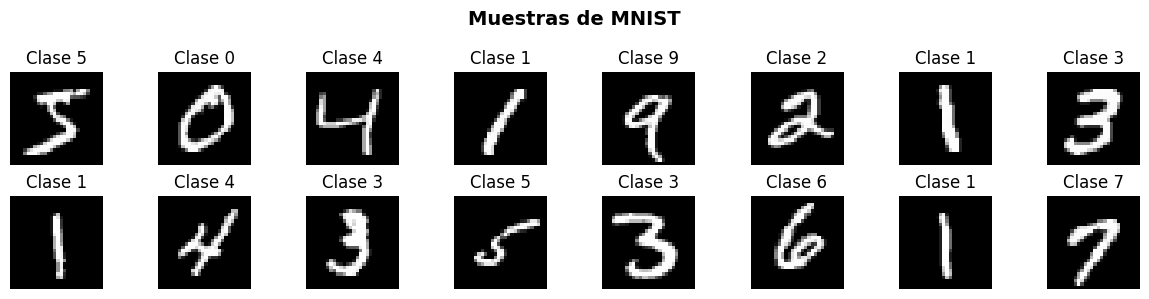

In [ ]:
if keras is not None:
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for ax, img, label in zip(axes.ravel(), x_train[:16], y_train[:16]):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(f"Clase {label}")
        ax.axis("off")
    plt.suptitle("Muestras de MNIST", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("TensorFlow/Keras no disponible.")

### 9.1 Mini-Inception para MNIST

La red siguiente no pretende copiar GoogLeNet completa. Es una versión pequeña que conserva la idea principal: usar módulos Inception para procesar la imagen a múltiples escalas.

In [ ]:
def build_mini_inception(input_shape=(28, 28, 1), num_classes=10):
    if keras is None:
        raise ImportError("TensorFlow/Keras no está disponible.")

    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = inception_module(x, 16, 16, 24, 4, 8, 8, name="inc_1")
    x = layers.BatchNormalization()(x)

    x = inception_module(x, 24, 24, 32, 8, 12, 12, name="inc_2")
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = inception_module(x, 32, 24, 40, 8, 16, 16, name="inc_3")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="Mini_Inception_MNIST")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

if keras is not None:
    mini_model = build_mini_inception()
    mini_model.summary()
else:
    print("TensorFlow/Keras no disponible.")

Model: "Mini_Inception_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_3x3_reduce    │ (None, 14, 14,    │        528 │ max_pooling2d[0]… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_5x5_reduce    │ (None, 14, 14, 4) │        132 │ max_pooling2d[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_pool          │ (None, 14, 14,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_1x1 (Conv2D)  │ (None, 14, 14,    │        528 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_3x3 (Conv2D)  │ (None, 14, 14,    │      3,480 │ inc_1_3x3_reduce… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_5x5 (Conv2D)  │ (None, 14, 14, 8) │        808 │ inc_1_5x5_reduce… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_pool_proj     │ (None, 14, 14, 8) │        264 │ inc_1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_1_concat        │ (None, 14, 14,    │          0 │ inc_1_1x1[0][0],  │
│ (Concatenate)       │ 56)               │            │ inc_1_3x3[0][0],  │
│                     │                   │            │ inc_1_5x5[0][0],  │
│                     │                   │            │ inc_1_pool_proj[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        224 │ inc_1_concat[0][… │
│ (BatchNormalizatio… │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_2_3x3_reduce    │ (None, 14, 14,    │      1,368 │ batch_normalizat… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_2_5x5_reduce    │ (None, 14, 14, 8) │        456 │ batch_normalizat… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc_2_pool          │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 39,390 (153.87 KB)

 Trainable params: 39,054 (152.55 KB)

 Non-trainable params: 336 (1.31 KB)

In [ ]:
if keras is not None:
    history = mini_model.fit(
        x_train, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )
else:
    history = None
    print("TensorFlow/Keras no disponible.")

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step - accuracy: 0.4795 - loss: 1.5835 - val_accuracy: 0.1111 - val_loss: 2.7129
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8696 - loss: 0.4615 - val_accuracy: 0.1111 - val_loss: 3.3999
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9391 - loss: 0.2171 - val_accuracy: 0.1122 - val_loss: 3.7307
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9561 - loss: 0.1495 - val_accuracy: 0.1878 - val_loss: 3.4492
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9671 - loss: 0.1134 - val_accuracy: 0.2083 - val_loss: 3.0084
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9709 - loss: 0.0942 - val_accuracy: 0.5106 - val_loss: 1.3822
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9771 - loss: 0.0767 - val_accuracy: 0.7389 - val_loss: 0.7795
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9803 - loss: 0.0663 - val_accuracy: 0.9217 -

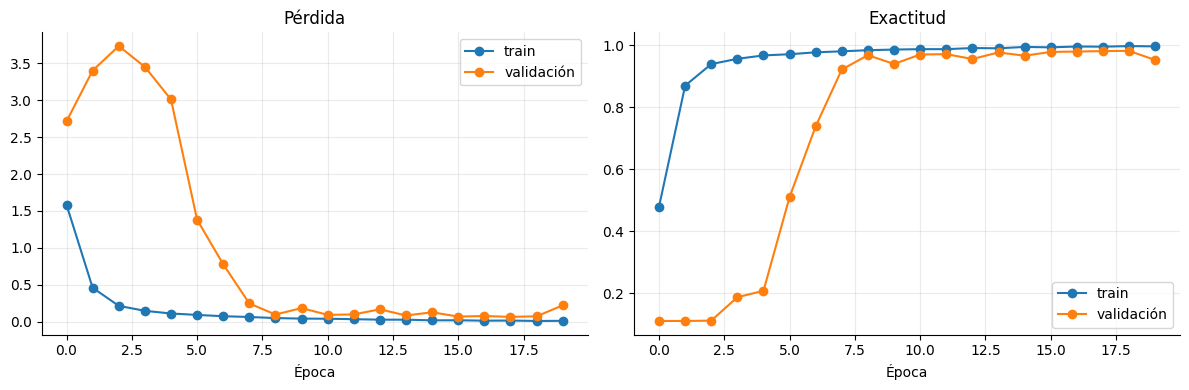

In [ ]:
def plot_training_history(history):
    if history is None:
        print("No hay historial de entrenamiento.")
        return

    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["loss"], marker="o", label="train")
    axes[0].plot(hist["val_loss"], marker="o", label="validación")
    axes[0].set_title("Pérdida")
    axes[0].set_xlabel("Época")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(hist["accuracy"], marker="o", label="train")
    axes[1].plot(hist["val_accuracy"], marker="o", label="validación")
    axes[1].set_title("Exactitud")
    axes[1].set_xlabel("Época")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
if keras is not None:
    test_loss, test_acc = mini_model.evaluate(x_test, y_test, verbose=0)
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
else:
    print("TensorFlow/Keras no disponible.")

Test loss: 0.1884
Test accuracy: 0.9484


### 9.2 Matriz de confusión y predicciones

Además de una métrica global, conviene revisar dónde se equivoca la red. La matriz de confusión muestra qué clases tiende a confundir.

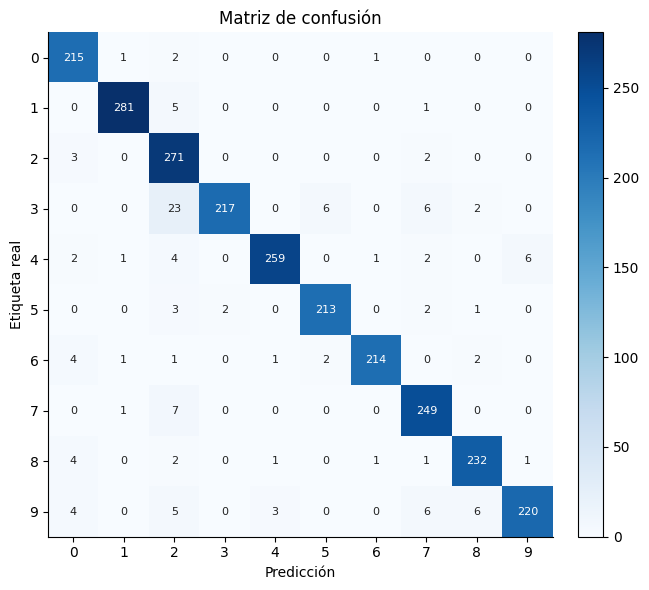

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = np.zeros((len(class_names), len(class_names)), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[int(true), int(pred)] += 1

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Matriz de confusión")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    threshold = cm.max() * 0.65
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "#222"
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8, color=color)
    plt.tight_layout()
    plt.show()

if keras is not None:
    probs = mini_model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    preds = probs.argmax(axis=1)
    plot_confusion_matrix(y_test, preds, [str(i) for i in range(10)])
else:
    print("TensorFlow/Keras no disponible.")

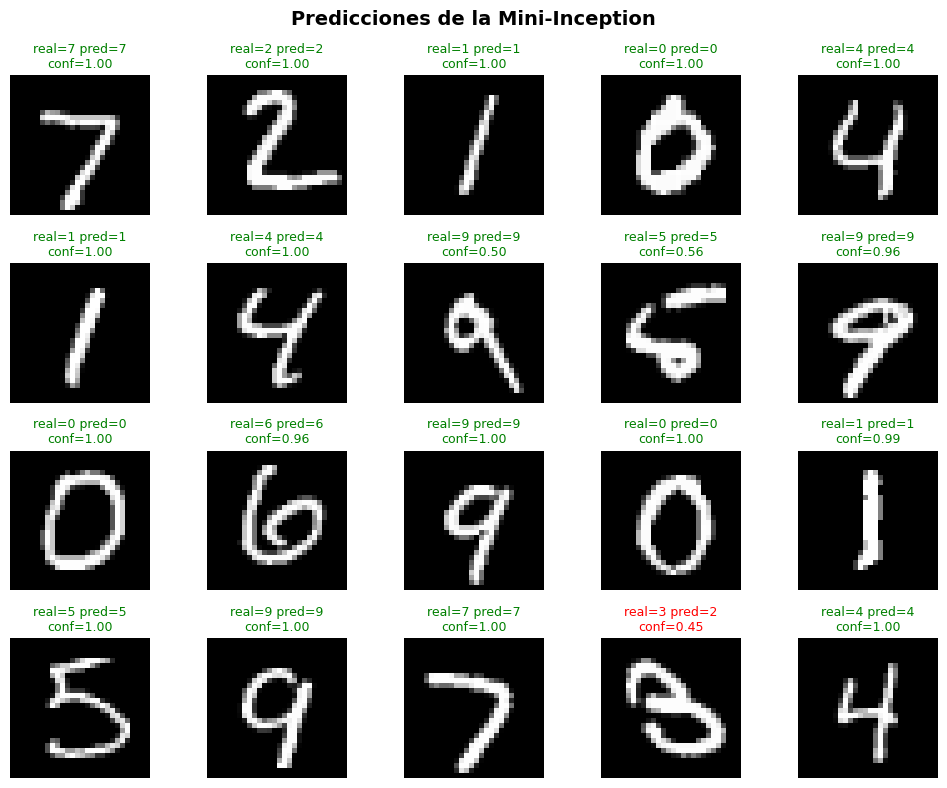

In [ ]:
if keras is not None:
    n = 20
    fig, axes = plt.subplots(4, 5, figsize=(10, 8))
    for ax, img, true, pred, prob in zip(axes.ravel(), x_test[:n], y_test[:n], preds[:n], probs[:n]):
        ax.imshow(img.squeeze(), cmap="gray")
        color = "green" if true == pred else "red"
        ax.set_title(f"real={true} pred={pred}\nconf={prob[pred]:.2f}", color=color, fontsize=9)
        ax.axis("off")
    plt.suptitle("Predicciones de la Mini-Inception", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("TensorFlow/Keras no disponible.")

### 9.3 Visualización de activaciones internas

Una forma atractiva de entender una CNN es mirar algunos mapas de activación. Aquí observamos salidas del primer módulo Inception.

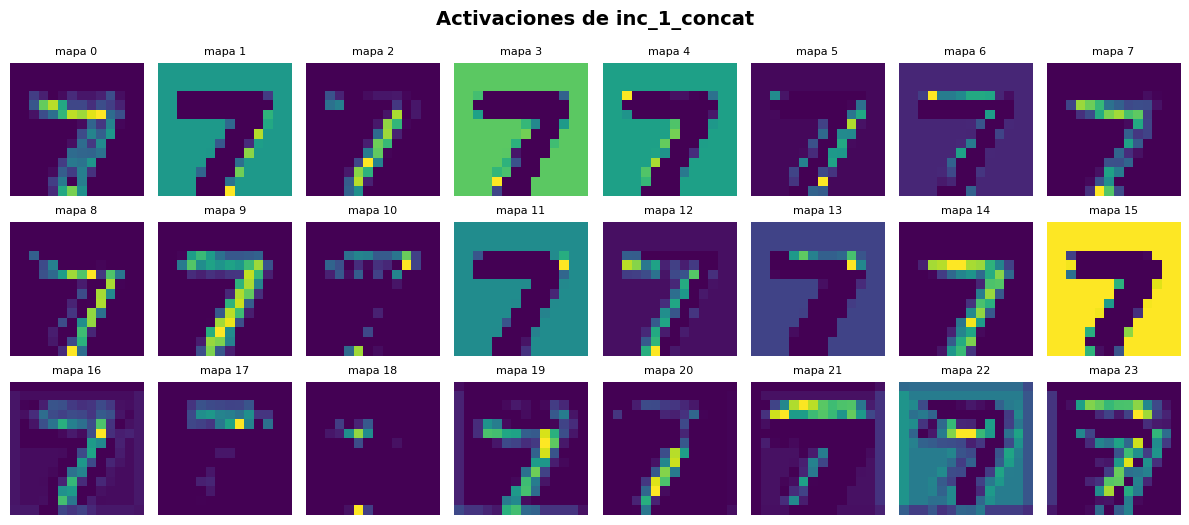

In [ ]:
def show_activation_maps(model, image, layer_name="inc_1_concat", max_maps=16):
    if keras is None:
        print("TensorFlow/Keras no disponible.")
        return

    activation_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output,
    )
    activations = activation_model.predict(image[None, ...], verbose=0)[0]
    maps = min(max_maps, activations.shape[-1])

    cols = 8
    rows = math.ceil(maps / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 1.8 * rows))
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < maps:
            ax.imshow(activations[:, :, i], cmap="viridis")
            ax.set_title(f"mapa {i}", fontsize=8)

    plt.suptitle(f"Activaciones de {layer_name}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

if keras is not None:
    show_activation_maps(mini_model, x_test[0], layer_name="inc_1_concat", max_maps=24)
else:
    print("TensorFlow/Keras no disponible.")

### 9.4 Variante opcional: Mini-Inception para CIFAR-10

CIFAR-10 es más desafiante que MNIST porque contiene imágenes RGB de objetos reales en baja resolución. Esta celda define una variante para CIFAR-10. Está pensada como demostración adicional; si tienes poco tiempo, puedes dejarla sin ejecutar.

In [ ]:
def build_cifar_mini_inception(input_shape=(32, 32, 3), num_classes=10):
    if keras is None:
        raise ImportError("TensorFlow/Keras no está disponible.")

    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255.0)(inputs)

    x = layers.Conv2D(48, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = inception_module(x, 24, 24, 32, 8, 16, 16, name="cifar_inc_1")
    x = layers.BatchNormalization()(x)
    x = inception_module(x, 32, 32, 48, 8, 16, 16, name="cifar_inc_2")
    x = layers.MaxPooling2D(2)(x)

    x = inception_module(x, 48, 32, 64, 12, 24, 24, name="cifar_inc_3")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="Mini_Inception_CIFAR10")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

if keras is not None:
    cifar_model = build_cifar_mini_inception()
    cifar_model.summary()
else:
    print("TensorFlow/Keras no disponible.")

Model: "Mini_Inception_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 32, 32, 3) │          0 │ input_layer_1[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      1,344 │ rescaling[0][0]   │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_3x3_re… │ (None, 16, 16,    │      1,176 │ max_pooling2d_2[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_5x5_re… │ (None, 16, 16, 8) │        392 │ max_pooling2d_2[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_pool    │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_1x1     │ (None, 16, 16,    │      1,176 │ max_pooling2d_2[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_3x3     │ (None, 16, 16,    │      6,944 │ cifar_inc_1_3x3_… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_5x5     │ (None, 16, 16,    │      3,216 │ cifar_inc_1_5x5_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_pool_p… │ (None, 16, 16,    │        784 │ cifar_inc_1_pool… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_1_concat  │ (None, 16, 16,    │          0 │ cifar_inc_1_1x1[… │
│ (Concatenate)       │ 88)               │            │ cifar_inc_1_3x3[… │
│                     │                   │            │ cifar_inc_1_5x5[… │
│                     │                   │            │ cifar_inc_1_pool… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        352 │ cifar_inc_1_conc… │
│ (BatchNormalizatio… │ 88)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_2_3x3_re… │ (None, 16, 16,    │      2,848 │ batch_normalizat… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar_inc_2_5x5_re… │ (None, 16, 16, 8) │        712 │ batch_normalizat… │
│ (Conv2D)            │                   │            │                 

 Total params: 80,934 (316.15 KB)

 Trainable params: 80,662 (315.09 KB)

 Non-trainable params: 272 (1.06 KB)

In [ ]:
# Ejecución opcional: descomenta este bloque para entrenar con CIFAR-10.
#
# if keras is not None:
#     (cx_train, cy_train), (cx_test, cy_test) = keras.datasets.cifar10.load_data()
#     cy_train = cy_train.squeeze()
#     cy_test = cy_test.squeeze()
#
#     CIFAR_TRAIN_SAMPLES = 15000
#     CIFAR_TEST_SAMPLES = 3000
#     cx_train_small = cx_train[:CIFAR_TRAIN_SAMPLES]
#     cy_train_small = cy_train[:CIFAR_TRAIN_SAMPLES]
#     cx_test_small = cx_test[:CIFAR_TEST_SAMPLES]
#     cy_test_small = cy_test[:CIFAR_TEST_SAMPLES]
#
#     cifar_history = cifar_model.fit(
#         cx_train_small, cy_train_small,
#         validation_split=0.15,
#         epochs=5,
#         batch_size=128,
#         verbose=1,
#     )
#     cifar_model.evaluate(cx_test_small, cy_test_small, verbose=1)
#     plot_training_history(cifar_history)

## 10. Ventajas, limitaciones y conclusiones

### Ventajas

- Captura patrones a múltiples escalas en un mismo bloque.
- Reduce costo computacional gracias a convoluciones `1x1`.
- Permite redes profundas con menos parámetros que diseños densos tradicionales.
- Tuvo excelente desempeño histórico en ImageNet.
- Influyó en arquitecturas posteriores que usan bloques modulares, factorización y rutas paralelas.

### Limitaciones

- La arquitectura es más compleja de diseñar, implementar y ajustar.
- Las múltiples ramas pueden complicar la optimización y el despliegue.
- En muchos escenarios actuales ha sido superada por arquitecturas más modernas, como ResNet, EfficientNet, ConvNeXt, Vision Transformers y modelos híbridos.

### Conclusiones

Inception fue revolucionaria porque cambió la pregunta de diseño. En vez de decidir manualmente si una capa debía usar filtros `1x1`, `3x3` o `5x5`, permitió que la red combinara varias escalas en paralelo y aprendiera representaciones más ricas.

Su legado sigue vivo en tres ideas muy usadas:

- **Diseño modular** de bloques reutilizables.
- **Eficiencia mediante reducción de dimensionalidad**.
- **Procesamiento multi-rama** para capturar diferentes tipos de patrones.